## Real experiment — class-incremental MNIST, 2-layer MLP

Now the same "dance", but with **real accuracy**. MNIST digits 0–9 give exactly
**9 overlapping pair-tasks**: task 1 = {0,1}, task 2 = {1,2}, …, task 9 = {8,9}
(consecutive tasks share one digit, so we should see *partial* retention).

Protocol:
- **Model:** 2-layer MLP `784 → 256 → 10` (single shared 10-way head, class-incremental).
- **Training:** tasks in order; for each task, SGD only on examples of its two digits.
- **Eval:** after every few steps, accuracy of *every* task on its own held-out test digits.
- **Plot:** one bar per task; the trained task bumps up, earlier tasks sag = real forgetting.


In [1]:
# Load MNIST (HF datasets) and build the 9 overlapping pair-tasks.
import numpy as np
import torch
import torch.nn as nn
from datasets import load_dataset

torch.manual_seed(0); np.random.seed(0)

mnist = load_dataset("mnist")

def to_arrays(split):
    X = np.stack([np.asarray(im, dtype=np.float32) for im in split["image"]])
    X = X.reshape(len(X), -1) / 255.0
    y = np.asarray(split["label"], dtype=np.int64)
    return torch.from_numpy(X), torch.from_numpy(y)

Xtr, ytr = to_arrays(mnist["train"])
Xte, yte = to_arrays(mnist["test"])

TASKS = [(d, d + 1) for d in range(9)]          # {0,1}, {1,2}, ..., {8,9}
TASK_NAMES = [f"{a}|{b}" for a, b in TASKS]

train_idx = [torch.where((ytr == a) | (ytr == b))[0] for a, b in TASKS]
TEST_CAP = 1000                                  # per-task eval subsample (speed)
test_idx = []
for a, b in TASKS:
    idx = torch.where((yte == a) | (yte == b))[0]
    test_idx.append(idx[torch.randperm(len(idx))[:TEST_CAP]])

print("train sizes:", [len(i) for i in train_idx])
print("test  sizes:", [len(i) for i in test_idx])


train sizes: [12665, 12700, 12089, 11973, 11263, 11339, 12183, 12116, 11800]
test  sizes: [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]


In [2]:
# Train once, sequentially over the 9 tasks; record 10-way acc, pair-restricted acc, mean logits.
torch.manual_seed(0); np.random.seed(0)
model = nn.Sequential(nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 10))
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
STEPS_PER_TASK, BATCH, EVAL_EVERY = 150, 128, 10
PROBE = torch.randperm(len(Xte))[:2000]        # fixed probe set for logit stats

@torch.no_grad()
def eval_tasks():
    model.eval()
    a10, a2 = [], []
    for (a, b), idx in zip(TASKS, test_idx):
        lg = model(Xte[idx])
        a10.append((lg.argmax(1) == yte[idx]).float().mean().item())
        pred = torch.where(lg[:, [a, b]].argmax(1) == 0, torch.tensor(a), torch.tensor(b))
        a2.append((pred == yte[idx]).float().mean().item())
    ml = model(Xte[PROBE]).mean(0).tolist()
    model.train()
    return a10, a2, ml

hist = {"a10": [], "a2": [], "logit": [], "task": [], "tick": []}
def record(t, s):
    a10_, a2_, ml_ = eval_tasks()
    for k, v in zip(("a10", "a2", "logit", "task", "tick"), (a10_, a2_, ml_, t, s)):
        hist[k].append(v)

record(-1, 0)
step = 0
for t, idx in enumerate(train_idx):
    for _ in range(STEPS_PER_TASK):
        b = idx[torch.randint(len(idx), (BATCH,))]
        loss = loss_fn(model(Xtr[b]), ytr[b])
        opt.zero_grad(); loss.backward(); opt.step()
        step += 1
        if step % EVAL_EVERY == 0:
            record(t, step)

a10, a2 = np.array(hist["a10"]), np.array(hist["a2"])
logits_h, ticks = np.array(hist["logit"]), np.array(hist["tick"])
print("final 10-way:", a10[-1].round(2), "\nfinal 2-way :", a2[-1].round(2))

final 10-way: [0.   0.   0.   0.   0.   0.   0.   0.48 0.98] 
final 2-way : [0.58 0.64 0.51 0.95 0.9  0.93 0.78 0.5  0.98]


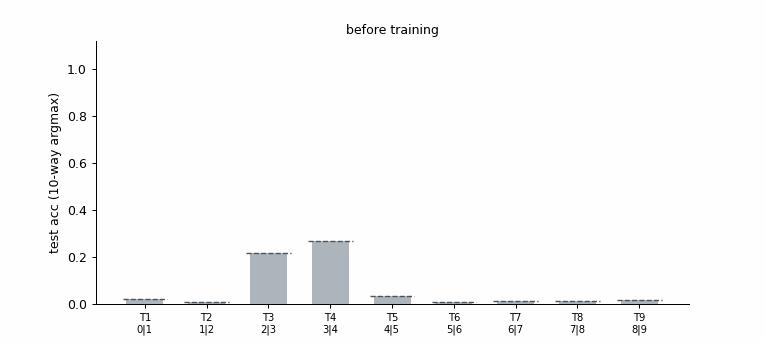

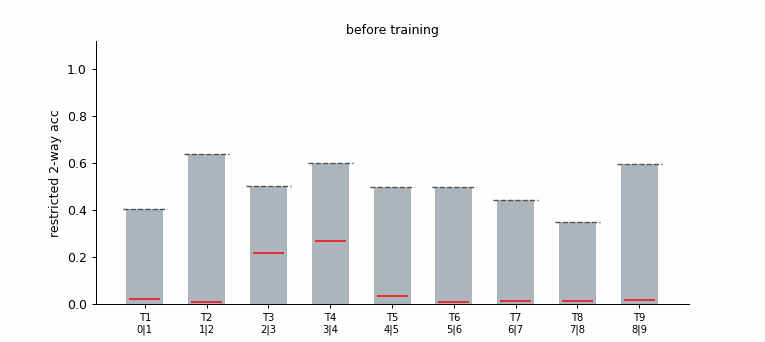

In [3]:
# The two dances: raw 10-way argmax vs pair-restricted (task-recency bias ablated).
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image as IPImage, display

NT = len(TASKS); Xb = np.arange(NT)
C_IDLE, C_TRAIN, C_PEAK, C_DROP = "#adb5bd", "#f08c00", "#495057", "#e03131"

def make_gif(acc, fname, ylabel, extra=None, task_seq=None, tick_arr=None):
    task_seq = hist["task"] if task_seq is None else task_seq
    tick_arr = ticks if tick_arr is None else tick_arr
    peak = np.maximum.accumulate(acc, axis=0)
    fig, ax = plt.subplots(figsize=(8.5, 3.8))
    def update(k):
        ax.clear()
        cur = task_seq[k]
        ax.bar(Xb, acc[k], width=0.6, zorder=2,
               color=[C_TRAIN if i == cur else C_IDLE for i in range(NT)])
        for i in range(NT):
            ax.hlines(peak[k, i], Xb[i] - .36, Xb[i] + .36, color=C_PEAK, ls="--", lw=1.1)
            if extra is not None:
                ax.hlines(extra[k, i], Xb[i] - .25, Xb[i] + .25, color=C_DROP, lw=1.6)
        ax.set_ylim(0, 1.12); ax.set_xticks(Xb)
        ax.set_xticklabels([f"T{i+1}\n{TASK_NAMES[i]}" for i in range(NT)], fontsize=8)
        ax.set_ylabel(ylabel)
        ax.set_title("before training" if cur < 0 else
                     f"step {tick_arr[k]} — training task {cur+1} ({TASK_NAMES[cur]})", fontsize=10)
        ax.spines[["top", "right"]].set_visible(False)
    FuncAnimation(fig, update, frames=len(acc), interval=90).save(
        fname, writer=PillowWriter(fps=11), dpi=90)
    plt.close(fig)
    display(IPImage(filename=fname))

make_gif(a10, "imagine_lgap_mnist_dance.gif", "test acc (10-way argmax)")
make_gif(a2, "imagine_lgap_mnist_dance_restricted.gif",
         "restricted 2-way acc", extra=a10)   # red dash = raw 10-way for contrast

In [4]:
# [Observation] the 2 correlation is rather explained better by a single outlier (versus an actual phenomenon)
# [Better Question]. Is 'hidden overlap' varying with different training order, or is it a "innate property" determined by (mode, data) pair 

wave order: 1|2 -> 8|9 -> 0|1 -> 7|8 -> 4|5 -> 6|7 -> 5|6 -> 2|3 -> 3|4
sequential final: [0.63 0.97 0.5  0.58 0.77 0.8  0.59 0.5  0.98] | mean 0.703
wave final      : [0.95 0.64 0.5  0.99 0.53 0.7  0.86 0.81 0.44] | mean 0.714


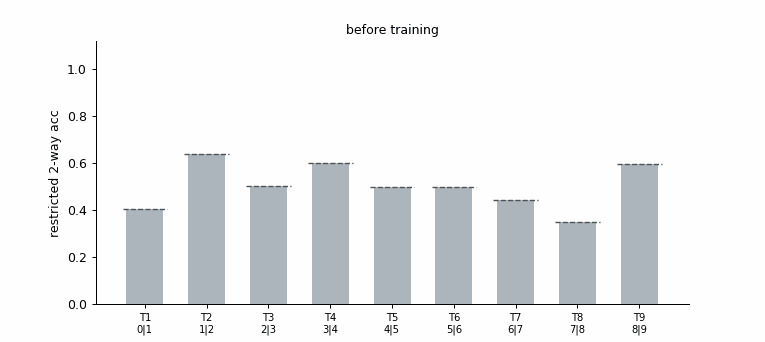

In [5]:
# [Request] "wave" curriculum: always train the currently-EASIEST untrained task
# (highest current restricted acc), so acquisition rolls through tasks like a wave.
# Compare final restricted accs vs the sequential order.
def run_sequence(order=None, greedy=False, seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    m = nn.Sequential(nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 10))
    o = torch.optim.Adam(m.parameters(), lr=1e-3)

    @torch.no_grad()
    def eval_r2():
        m.eval()
        out = []
        for (a, b), idx in zip(TASKS, test_idx):
            lg = m(Xte[idx])
            pred = torch.where(lg[:, [a, b]].argmax(1) == 0, torch.tensor(a), torch.tensor(b))
            out.append((pred == yte[idx]).float().mean().item())
        m.train()
        return out

    h = {"a2": [eval_r2()], "task": [-1], "tick": [0]}
    remaining, seq, step = list(range(NT)), [], 0
    while remaining:
        t = (max(remaining, key=lambda i: h["a2"][-1][i]) if greedy
             else order[len(seq)])
        seq.append(t); remaining.remove(t)
        idx = train_idx[t]
        for _ in range(STEPS_PER_TASK):
            b = idx[torch.randint(len(idx), (BATCH,))]
            loss = loss_fn(m(Xtr[b]), ytr[b])
            o.zero_grad(); loss.backward(); o.step()
            step += 1
            if step % EVAL_EVERY == 0:
                h["a2"].append(eval_r2()); h["task"].append(t); h["tick"].append(step)
    return np.array(h["a2"]), h["task"], np.array(h["tick"]), seq

a2_base, _, _, _ = run_sequence(order=list(range(NT)))
a2_wave, task_wave, ticks_wave, seq_wave = run_sequence(greedy=True)

print("wave order:", " -> ".join(TASK_NAMES[t] for t in seq_wave))
print(f"sequential final: {a2_base[-1].round(2)} | mean {a2_base[-1].mean():.3f}")
print(f"wave final      : {a2_wave[-1].round(2)} | mean {a2_wave[-1].mean():.3f}")

make_gif(a2_wave, "imagine_lgap_mnist_dance_wave.gif", "restricted 2-way acc",
         task_seq=task_wave, tick_arr=ticks_wave)

correlation of the 45 off-diagonal overlaps between conditions:
         pixels  random init        joint  seq 1..9 s0  seq 9..1 s0      perm s0
       pixels          1.00         0.97         0.92         0.39         0.75         0.84
  random init          0.97         1.00         0.84         0.31         0.83         0.85
        joint          0.92         0.84         1.00         0.43         0.54         0.69
  seq 1..9 s0          0.39         0.31         0.43         1.00         0.15         0.36
  seq 9..1 s0          0.75         0.83         0.54         0.15         1.00         0.88
      perm s0          0.84         0.85         0.69         0.36         0.88         1.00


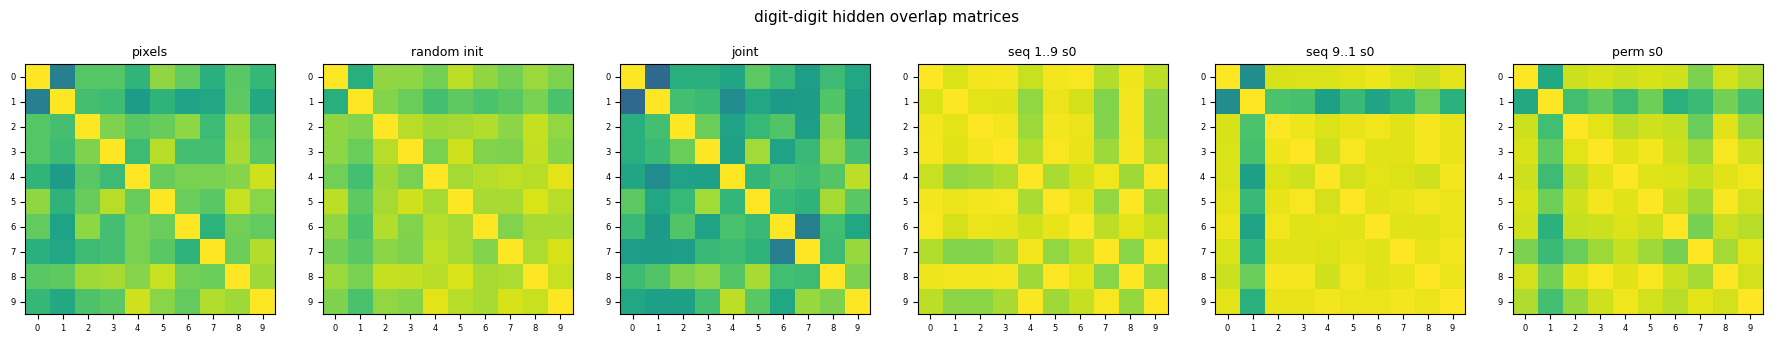

In [6]:
# [Motivate] does sequential training COLLAPSE old tasks' representations, and is the
# collapse order-dependent (training history) or innate to the (model, data) pair?
# Overlap M[i, j] = cosine(mean hidden activation of digit i, digit j), a 10x10 matrix.

@torch.no_grad()
def overlap_matrix(feat_fn):
    class_means = torch.stack([feat_fn(Xte[yte == d]).mean(0) for d in range(10)])
    class_means = class_means / class_means.norm(dim=1, keepdim=True)
    return (class_means @ class_means.T).numpy()

def fresh(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    return nn.Sequential(nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 10))

def train_order(order, seed=0):
    model = fresh(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    for task in order:
        candidates = train_idx[task]
        for _ in range(STEPS_PER_TASK):
            batch = candidates[torch.randint(len(candidates), (BATCH,))]
            loss = loss_fn(model(Xtr[batch]), ytr[batch])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return model

def train_joint(seed=0):
    model = fresh(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    for _ in range(STEPS_PER_TASK * NT):
        batch = torch.randint(len(Xtr), (BATCH,))
        loss = loss_fn(model(Xtr[batch]), ytr[batch])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return model

def hidden(model):
    return lambda x: torch.relu(model[0](x))

example_perm = [int(t) for t in np.random.default_rng(0).permutation(NT)]
overlap_mats = {
    "pixels": overlap_matrix(lambda x: x),
    "random init": overlap_matrix(hidden(fresh(0))),
    "joint": overlap_matrix(hidden(train_joint(seed=0))),
    "seq 1..9 s0": overlap_matrix(hidden(train_order(range(NT), seed=0))),
    "seq 9..1 s0": overlap_matrix(hidden(train_order(range(NT - 1, -1, -1), seed=0))),
    "perm s0": overlap_matrix(hidden(train_order(example_perm, seed=0))),
}

off_diag = np.triu_indices(10, k=1)
names = list(overlap_mats)
print("correlation of the 45 off-diagonal overlaps between conditions:")
print("  " + "".join(f"{name:>13}" for name in names))
for name_a in names:
    row = [np.corrcoef(overlap_mats[name_a][off_diag], overlap_mats[name_b][off_diag])[0, 1]
           for name_b in names]
    print(f"{name_a:>13} " + "".join(f"{value:>13.2f}" for value in row))

fig, axes = plt.subplots(1, len(names), figsize=(3 * len(names), 3.1))
for ax, name in zip(axes, names):
    ax.imshow(overlap_mats[name], vmin=0, vmax=1, cmap="viridis")
    ax.set_title(name, fontsize=9)
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.tick_params(labelsize=6)
plt.suptitle("digit-digit hidden overlap matrices", y=1.03, fontsize=11)
plt.tight_layout()
plt.show()

# [Takeaway] sequential runs are far more collapsed than joint, and their overlap
# patterns disagree across orders -> collapse is made by training history, not innate.
# Hypothesis to validate: this collapse IS forgetting, i.e. it predicts how hard a
# task's memory is to recover (low-k decodability), measured next.

In [ ]:
# [Observation]. 
# In every ordered training settings, old task representations "collapses" more -- (most of) they becomes similar to each other, the last-trained
# task has unique representations. 

# Hypothesis: Forget correlates with Representation Collapse
# [Validation 1]. Compared to joint training, ordered training has much heavier 'representation collapse'
# [Validation 2]. Across 60 runs, 580 tasks, we observe correlation with representatino collapse and heavier forgetting (low decodability)

In [10]:
# [Probe toolkit] memory = how easily a task is re-decoded from FROZEN features with
# few labels (full-data probes saturate: even random features reach 0.98).
#   binary probe — 1 logit, task identity GIVEN (only that pair's examples)
#   10-way probe — 10 logits, task-AGNOSTIC full argmax (the LM-like setting)

def frozen_features(model):
    """Hidden-layer activations of a frozen trunk on the full train / test sets."""
    with torch.no_grad():
        return torch.relu(model[0](Xtr)), torch.relu(model[0](Xte))

def fit_binary_probe(train_feats, train_labels, test_feats, test_labels, steps=200):
    """Fit a fresh 1-logit readout ("is it digit b?"); return test accuracy."""
    probe = nn.Linear(train_feats.shape[1], 1)
    optimizer = torch.optim.Adam(probe.parameters(), lr=5e-2)
    for _ in range(steps):
        loss = nn.functional.binary_cross_entropy_with_logits(
            probe(train_feats)[:, 0], train_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    with torch.no_grad():
        predictions = probe(test_feats)[:, 0] > 0
        return (predictions.float() == test_labels).float().mean().item()

def kshot_decodability(train_feats, test_feats, task, shots_per_class, num_draws=5):
    """Mean binary-probe accuracy on one pair-task, k labeled examples per class."""
    digit_a, digit_b = TASKS[task]
    candidates_a = np.where(ytr.numpy() == digit_a)[0]
    candidates_b = np.where(ytr.numpy() == digit_b)[0]
    task_test_feats = test_feats[test_idx[task]]
    task_test_labels = (yte[test_idx[task]] == digit_b).float()
    total_acc = 0.0
    for draw in range(num_draws):
        rng = np.random.default_rng(1000 * task + 10 * shots_per_class + draw)
        selected = np.concatenate([
            rng.choice(candidates_a, shots_per_class, replace=False),
            rng.choice(candidates_b, shots_per_class, replace=False),
        ])
        torch.manual_seed(draw)
        total_acc += fit_binary_probe(
            train_feats[selected], (ytr[selected] == digit_b).float(),
            task_test_feats, task_test_labels)
    return total_acc / num_draws

def tenway_kshot_per_task(train_feats, test_feats, shots_per_class=1, num_draws=10):
    """Task-agnostic decodability: per-task accuracy of a fresh 10-way readout."""
    per_task_acc = np.zeros(NT)
    for draw in range(num_draws):
        rng = np.random.default_rng(500 + draw)
        selected = np.concatenate([
            rng.choice(np.where(ytr.numpy() == digit)[0], shots_per_class, replace=False)
            for digit in range(10)
        ])
        torch.manual_seed(draw)
        probe = nn.Linear(train_feats.shape[1], 10)
        optimizer = torch.optim.Adam(probe.parameters(), lr=5e-2)
        for _ in range(200):
            loss = nn.functional.cross_entropy(probe(train_feats[selected]), ytr[selected])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        with torch.no_grad():
            predicted_digit = probe(test_feats).argmax(dim=1)
        for task in range(NT):
            split = test_idx[task]
            per_task_acc[task] += (predicted_digit[split] == yte[split]).float().mean().item()
    return per_task_acc / num_draws

run level (n=60):
  corr(collapse, k=1 binary acc) = -0.01
  corr(collapse, k=1 10-way acc) = -0.03
task level, last-trained task excluded (n=480):
  corr(pair overlap, binary acc) = -0.59
  corr(pair overlap, 10-way acc) = -0.42


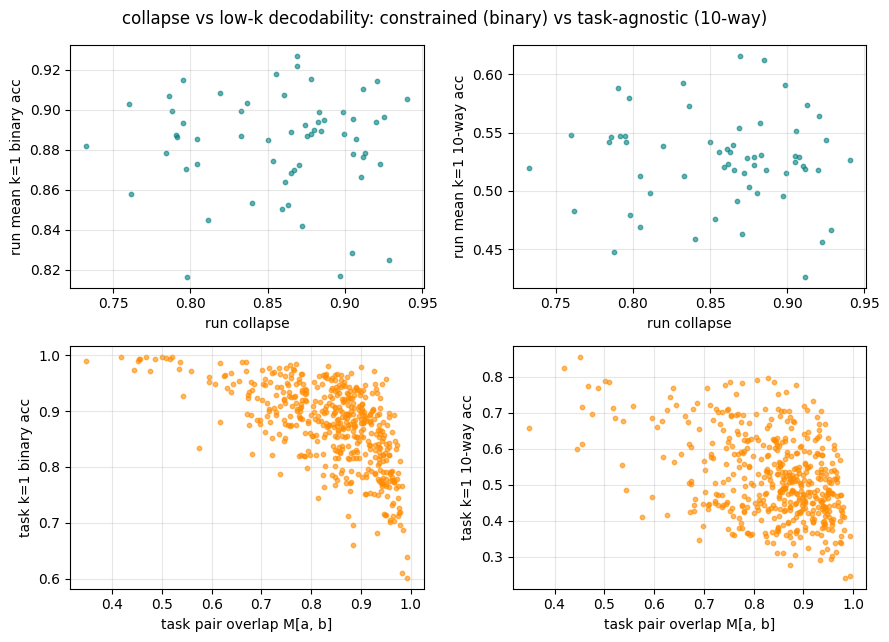

In [11]:
# [Validate] Hypothesis: representation collapse predicts loss of recoverable memory
# (k=1 decodability), for BOTH probe variants. 30 curricula (1..9, 9..1, 28 random
# permutations) x 2 init seeds = 60 runs. The last-trained task of each run is excluded
# from task-level stats (trivially fresh -> would manufacture correlation).
order_rng = np.random.default_rng(7)
curricula = [list(range(NT)), list(range(NT - 1, -1, -1))]
curricula += [[int(task) for task in order_rng.permutation(NT)] for _ in range(28)]

run_stats, task_stats = [], []      # run: (collapse, mean binary, mean 10-way)
for order in curricula:             # task: (pair overlap, binary, 10-way)
    for seed in (0, 1):
        model = train_order(order, seed=seed)
        overlap = overlap_matrix(hidden(model))
        train_feats, test_feats = frozen_features(model)
        tenway_acc = tenway_kshot_per_task(train_feats, test_feats)
        binary_acc = [kshot_decodability(train_feats, test_feats, task,
                                         shots_per_class=1, num_draws=10)
                      for task in range(NT)]
        run_stats.append((overlap[np.triu_indices(10, 1)].mean(),
                          np.mean(binary_acc), tenway_acc.mean()))
        task_stats += [(overlap[a, b], binary_acc[task], tenway_acc[task])
                       for task, (a, b) in enumerate(TASKS) if task != order[-1]]

run_collapse, run_binary, run_tenway = np.array(run_stats).T
task_overlap, task_binary, task_tenway = np.array(task_stats).T
print(f"run level (n={len(run_collapse)}):")
print(f"  corr(collapse, k=1 binary acc) = {np.corrcoef(run_collapse, run_binary)[0, 1]:+.2f}")
print(f"  corr(collapse, k=1 10-way acc) = {np.corrcoef(run_collapse, run_tenway)[0, 1]:+.2f}")
print(f"task level, last-trained task excluded (n={len(task_overlap)}):")
print(f"  corr(pair overlap, binary acc) = {np.corrcoef(task_overlap, task_binary)[0, 1]:+.2f}")
print(f"  corr(pair overlap, 10-way acc) = {np.corrcoef(task_overlap, task_tenway)[0, 1]:+.2f}")

panels = [
    (run_collapse, run_binary, "run collapse", "run mean k=1 binary acc", "teal"),
    (run_collapse, run_tenway, "run collapse", "run mean k=1 10-way acc", "teal"),
    (task_overlap, task_binary, "task pair overlap M[a, b]", "task k=1 binary acc", "darkorange"),
    (task_overlap, task_tenway, "task pair overlap M[a, b]", "task k=1 10-way acc", "darkorange"),
]
fig, axes = plt.subplots(2, 2, figsize=(9, 6.5))
for ax, (x, y, xlabel, ylabel, color) in zip(axes.flat, panels):
    ax.scatter(x, y, c=color, s=10, alpha=0.6)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
plt.suptitle("collapse vs low-k decodability: constrained (binary) vs task-agnostic (10-way)")
plt.tight_layout()
plt.show()

### Verdict at 5x scale (60 runs, 480 task points)

| level | binary (task given) | 10-way (task-agnostic) |
|---|---|---|
| task: corr(pair overlap, k=1 acc), n=480 | **−0.59** | **−0.42** |
| run: corr(collapse, mean k=1 acc), n=60 | −0.01 | −0.03 |

**The task-level relationship survives scaling; the run-level one does not.** With 12 runs
the run-level correlation (−0.53 / −0.43) was carried by the two extreme curricula
(`1..9`, `9..1`); 28 random permutations all land in a narrow collapse band, and within
that band mean decodability is noise — the earlier run-level number was small-n structure,
not signal.

The surviving claim is the sharper one anyway: **within a run, the tasks whose two class
prototypes were merged the most are the tasks a k=1 probe can no longer separate** — and
this holds even for the task-agnostic 10-way probe (the LM-transferable setting).
Collapse→forgetting is a per-task mechanism, not a whole-network summary statistic.

# [An idea for learning representations]
# - we want layer l-1 to obtain a rep that is generalizable 